In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
essays = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/essays.csv')
essays['short_description'] = essays['short_description'].astype(str)
essays['length'] = essays['short_description'].apply(len)


In [3]:
outcomes = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/outcomes.csv')
projects = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/projects.csv')
resources = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/resources.csv')
donations = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/donations.csv')

In [4]:
to_binary = {'f':0,'t':1}
outcomes['fully_funded'] = outcomes['fully_funded'].map(to_binary)
projects['eligible_double_your_impact_match'] = projects['eligible_double_your_impact_match'].map(to_binary)

In [5]:
outcomes.isna().sum()

projectid                                              0
is_exciting                                            0
at_least_1_teacher_referred_donor                  94398
fully_funded                                           0
at_least_1_green_donation                          94398
great_chat                                             0
three_or_more_non_teacher_referred_donors          94398
one_non_teacher_referred_donor_giving_100_plus     94398
donation_from_thoughtful_donor                     94398
great_messages_proportion                         179839
teacher_referred_count                             94398
non_teacher_referred_count                         94398
dtype: int64

In [6]:
projects.isna().sum()

projectid                                      0
teacher_acctid                                 0
schoolid                                       0
school_ncesid                              42736
school_latitude                                0
school_longitude                               0
school_city                                    0
school_state                                   0
school_zip                                     4
school_metro                               81908
school_district                              948
school_county                                 17
school_charter                                 0
school_magnet                                  0
school_year_round                              0
school_nlns                                    0
school_kipp                                    0
school_charter_ready_promise                   0
teacher_prefix                                 4
teacher_teach_for_america                      0
teacher_ny_teaching_

In [7]:
essays.isna().sum()

projectid               0
teacher_acctid          0
title                  17
short_description       0
need_statement       1472
essay                   3
length                  0
dtype: int64

In [8]:
resources.isna().sum()

resourceid                    0
projectid                     0
vendorid                 108269
vendor_name              108296
project_resource_type       196
item_name                 13711
item_number               25866
item_unit_price           13894
item_quantity              8310
dtype: int64

In [9]:
donations.isna().sum()

donationid                                        0
projectid                                         0
donor_acctid                                      0
donor_city                                  2005643
donor_state                                  603109
donor_zip                                   1712062
is_teacher_acct                                   0
donation_timestamp                                0
donation_to_project                               0
donation_optional_support                         0
donation_total                                    0
dollar_amount                                     0
donation_included_optional_support                0
payment_method                                    0
payment_included_acct_credit                      0
payment_included_campaign_gift_card               0
payment_included_web_purchased_gift_card          0
payment_was_promo_matched                         0
via_giving_page                                   0
for_honoree 

In [10]:
project_outcomes = projects.merge(outcomes,how='inner',on='projectid')
essay_outcomes = essays.merge(outcomes,how='inner',on='projectid')

In [39]:
features = ["school_state","primary_focus_subject","resource_type","poverty_level","grade_level","total_price_excluding_optional_support","total_price_including_optional_support","students_reached","eligible_double_your_impact_match"]
projects[features].isna().sum()

school_state                                0
primary_focus_subject                      39
resource_type                              45
poverty_level                               0
grade_level                                 9
total_price_excluding_optional_support      0
total_price_including_optional_support      0
students_reached                          146
eligible_double_your_impact_match           0
dtype: int64

In [40]:
features = ["essay","short_description","need_statement"]
essays[features].isna().sum()

essay                   3
short_description       0
need_statement       1472
dtype: int64

In [12]:
projects[numerical].describe()

,total_price_excluding_optional_support,total_price_including_optional_support,students_reached
count,6.640980e+05,6.640980e+05,663952.000000
mean,5.420415e+02,6.447128e+02,97.233547
std,1.267738e+04,1.545863e+04,2283.327661
min,0.000000e+00,0.000000e+00,0.000000
25%,2.672000e+02,3.175000e+02,22.000000
50%,4.110000e+02,4.878400e+02,30.000000
75%,5.864900e+02,6.963875e+02,100.000000
max,1.025002e+07,1.250002e+07,999999.000000


In [19]:
q = projects["total_price_excluding_optional_support"].quantile(0.99)
projects[projects["total_price_excluding_optional_support"] < q]["total_price_excluding_optional_support"].describe()

count    657457.000000
mean        475.589629
std         321.665941
min           0.000000
25%         265.480000
50%         408.280000
75%         576.780000
max        2387.900000
Name: total_price_excluding_optional_support, dtype: float64

<Axes: xlabel='total_price_excluding_optional_support'>

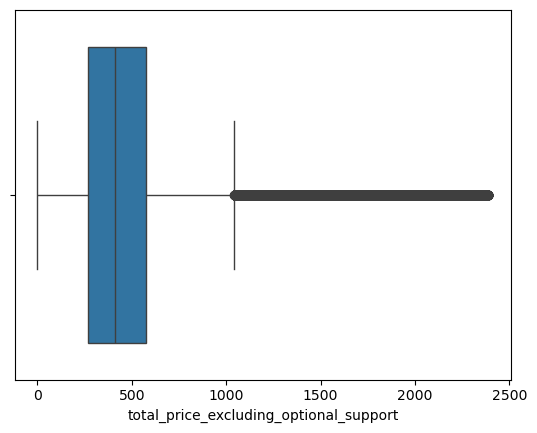

In [22]:
dropped_outliers = projects[projects["total_price_excluding_optional_support"] < q]["total_price_excluding_optional_support"]
sns.boxplot(x=dropped_outliers)

In [13]:
essay_outcomes['length'].describe()

count    619326.000000
mean        213.307563
std          49.909852
min           1.000000
25%         194.000000
50%         198.000000
75%         241.000000
max        1754.000000
Name: length, dtype: float64

In [16]:
project_outcomes.groupby('poverty_level')['fully_funded'].mean().sort_values(ascending=False)

poverty_level
highest poverty     0.726354
low poverty         0.669308
high poverty        0.658163
moderate poverty    0.639796
Name: fully_funded, dtype: float64

In [15]:
project_outcomes.groupby('resource_type')['fully_funded'].mean().sort_values(ascending=False)

resource_type
Books         0.762421
Trips         0.738100
Supplies      0.730294
Other         0.687430
Visitors      0.669231
Technology    0.614816
Name: fully_funded, dtype: float64

In [31]:
print(project_outcomes.groupby('school_state')['fully_funded'].mean().sort_values(ascending=False).head(),project_outcomes.groupby('school_state')['fully_funded'].mean().sort_values(ascending=False).tail())

school_state
La    1.000000
DC    0.805326
HI    0.803846
AK    0.787632
NH    0.787365
Name: fully_funded, dtype: float64 school_state
LA    0.621119
NC    0.611346
IA    0.610477
AL    0.592874
SC    0.562802
Name: fully_funded, dtype: float64


In [33]:
project_outcomes.groupby('school_state')['fully_funded'].mean().sort_values(ascending=False)

school_state
La    1.000000
DC    0.805326
HI    0.803846
AK    0.787632
NH    0.787365
WA    0.772802
NY    0.765421
CT    0.765323
DE    0.761449
NM    0.760978
MD    0.760147
MA    0.759240
NJ    0.755480
MT    0.755039
AR    0.736320
RI    0.733367
ID    0.728605
CA    0.728115
CO    0.727722
AZ    0.726907
VT    0.726547
ND    0.717241
IL    0.715337
OR    0.715252
SD    0.714769
WY    0.699482
MI    0.695617
MN    0.688346
ME    0.688271
UT    0.685051
PA    0.684496
NV    0.679352
MO    0.678404
IN    0.677990
KY    0.662577
WI    0.661639
OH    0.661442
NE    0.660167
VA    0.660043
OK    0.658393
WV    0.654867
TN    0.651889
FL    0.650020
KS    0.645802
TX    0.645134
MS    0.641951
GA    0.636575
LA    0.621119
NC    0.611346
IA    0.610477
AL    0.592874
SC    0.562802
Name: fully_funded, dtype: float64

In [14]:
project_outcomes.groupby('grade_level')['fully_funded'].mean().sort_values(ascending=False)

grade_level
Grades 9-12      0.717418
Grades PreK-2    0.695475
Grades 6-8       0.691063
Grades 3-5       0.687040
Name: fully_funded, dtype: float64

In [19]:
outcomes['fully_funded'].value_counts(normalize=True)

fully_funded
1    0.695406
0    0.304594
Name: proportion, dtype: float64

<Axes: xlabel='resource_type', ylabel='fully_funded'>

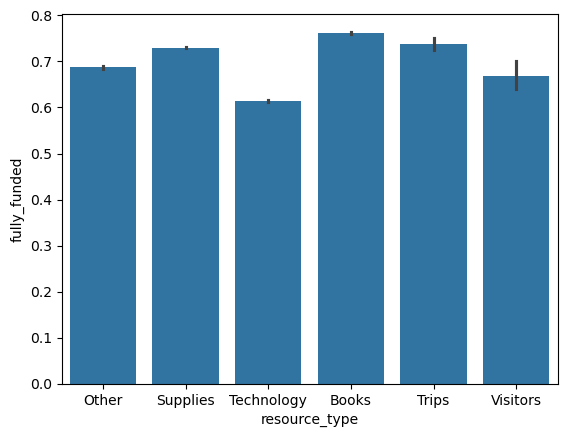

In [20]:
sns.barplot(x='resource_type', y='fully_funded', data=project_outcomes)

In [21]:
project_outcomes.groupby('primary_focus_subject')['fully_funded'].mean().sort_values(ascending=False)

primary_focus_subject
Nutrition                0.794326
Environmental Science    0.777787
Economics                0.766756
Music                    0.760829
Health & Life Science    0.747439
Sports                   0.738298
Performing Arts          0.729484
Visual Arts              0.729011
Applied Sciences         0.720853
Civics & Government      0.712999
Character Education      0.699716
History & Geography      0.697184
Health & Wellness        0.697046
Mathematics              0.695781
Community Service        0.691810
Social Sciences          0.690321
Literacy                 0.686502
Special Needs            0.679731
Literature & Writing     0.677855
Extracurricular          0.677564
Foreign Languages        0.665429
College & Career Prep    0.662970
ESL                      0.660615
Gym & Fitness            0.660555
Early Development        0.640826
Parent Involvement       0.598192
Other                    0.578355
Name: fully_funded, dtype: float64

In [22]:
project_outcomes.groupby('primary_focus_area')['fully_funded'].mean().sort_values(ascending=False)

primary_focus_area
Music & The Arts       0.740027
Math & Science         0.721912
History & Civics       0.699715
Health & Sports        0.696742
Literacy & Language    0.682890
Special Needs          0.679731
Applied Learning       0.640798
Name: fully_funded, dtype: float64

In [23]:
project_outcomes.groupby('grade_level')['fully_funded'].mean().sort_values(ascending=False)

grade_level
Grades 9-12      0.717418
Grades PreK-2    0.695475
Grades 6-8       0.691063
Grades 3-5       0.687040
Name: fully_funded, dtype: float64

In [24]:
project_outcomes.groupby('fully_funded')['fulfillment_labor_materials'].describe()

,count,mean,std,min,25%,50%,75%,max
fully_funded,,,,,,,,
0,177734.0,27.240545,8.723794,9.0,17.0,30.0,35.0,35.0
1,406510.0,27.331630,9.061253,9.0,17.0,30.0,35.0,35.0


<Axes: xlabel='poverty_level', ylabel='fully_funded'>

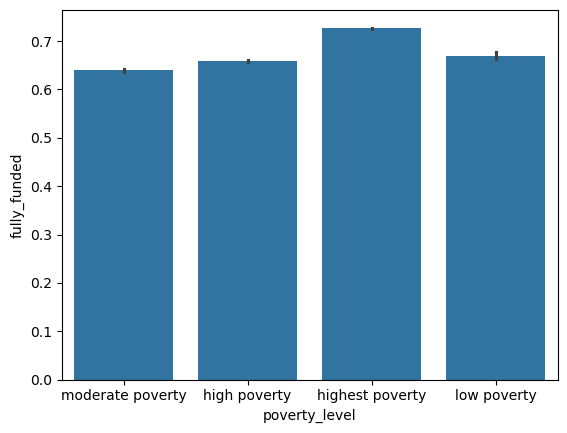

In [26]:
sns.barplot(x='poverty_level', y='fully_funded', data=project_outcomes)

<Axes: xlabel='grade_level', ylabel='fully_funded'>

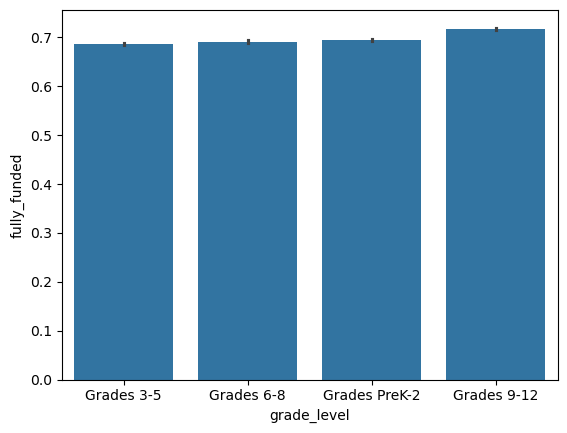

In [23]:
sns.barplot(x='grade_level', y='fully_funded', data=project_outcomes)

<Axes: xlabel='primary_focus_area', ylabel='fully_funded'>

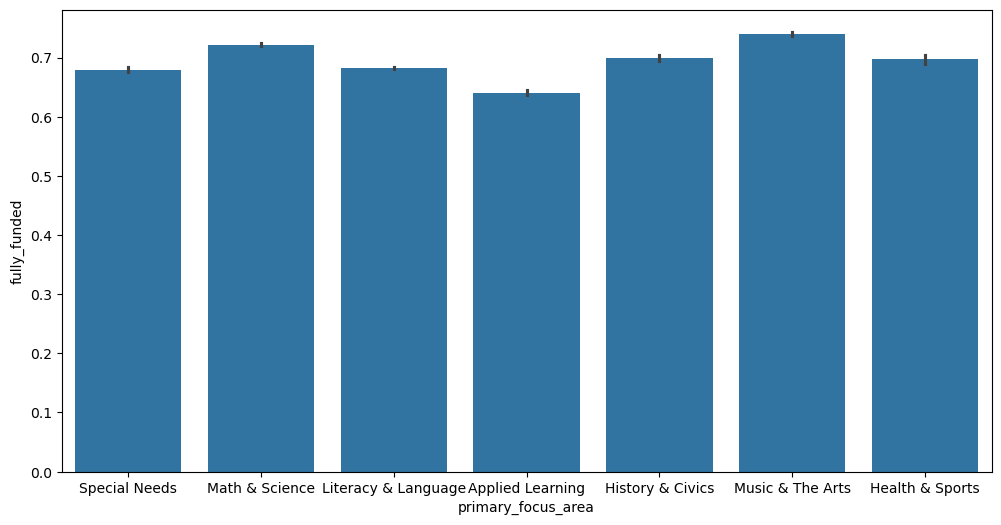

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x='primary_focus_area', y='fully_funded', data=project_outcomes)

In [28]:
essay_outcomes.groupby('fully_funded')['length'].agg(['mean','median'])

,mean,median
fully_funded,,
0,219.173131,198.0
1,210.738392,198.0


In [27]:
resource_outcomes = resources.merge(outcomes,how='inner',on='projectid')

In [28]:
resource_outcomes.groupby('fully_funded')['item_unit_price'].agg(['mean','median'])

,mean,median
fully_funded,,
0,87.618679,17.96
1,226.245461,12.99
